In [1]:
try:
    import numpy as np
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib.patches import Ellipse
    import matplotlib.ticker as ticker
    import matplotlib.gridspec as gridspec
except ImportError as e:
    print(f"Error importing libraries: {e}")
    print("Matplotlib and NumPy are required to generate the plots.")

try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except ImportError:
    print("SciencePlots is not installed. Using default Matplotlib style (plots will look different).")

from pathlib import Path

In [2]:
root = Path.cwd() / "../.."
iceIh_path = root / "data" / "IceIh"

if iceIh_path.exists():
    iceIh_10perc_data = np.load(root / "data" / "IceIh" / "iceIh_10perc_temps_plots.npy", allow_pickle=True).item()
    iceIh_10perc_taus = np.load(root / "data" / "IceIh" / "iceIh_10perc_taus.npy", allow_pickle=True).item()
else:
    raise FileNotFoundError(f"Data directory {iceIh_path} does not exist. Please ensure the data files are in the correct location.")

In [3]:
cmap_inf = plt.get_cmap('inferno')
cmap_vir = plt.get_cmap('viridis')
cmap_tab10 = plt.get_cmap('tab10')

colors_inf = [cmap_inf(i) for i in np.linspace(0.3, 0.9, 20)]
colors_vir = [cmap_vir(i) for i in np.linspace(0.3, 0.9, 20)]
colors_tab10 = [cmap_tab10(i) for i in range(20)]

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

In [4]:
label_map = {
    'OH_norm_heat_tau': r'$\tau_{stretch}^{unexc.}$',
    'HOH_exc_heat_tau': r'$\tau_{bend}^{exc.}$',
    'HOH_norm_tau': r'$\tau_{bend}^{unexc.}$',
    'HB_heat_tau': r'$\tau_{HB}$',
    'CMexc': r'$\tau_{CM}^{exc.}$',
    'CMnorm': r'$\tau_{CM}^{unexc.}$',
    'Lmean_norm_tau': r'$\tau_{libr}^{unexc.}$',
    'Lmean_exc_tau': r'$\tau_{libr}^{exc.}$'
}

In [5]:
OH_exc = iceIh_10perc_data["OH_exc"]
OH_norm_heat = iceIh_10perc_data["OH_norm_heat"]
OH_norm_cool = iceIh_10perc_data["OH_norm_cool"]
CMnorm = iceIh_10perc_data["CMnorm"]
CMexc = iceIh_10perc_data["CMexc"]
HOH_exc_heat = iceIh_10perc_data["HOH_exc_heat"]
HOH_exc_cool = iceIh_10perc_data["HOH_exc_cool"]
HOH_norm_heat = iceIh_10perc_data["HOH_norm_heat"]
HOH_norm_cool = iceIh_10perc_data["HOH_norm_cool"]
Lmean_norm_heat = iceIh_10perc_data["Lmean_norm_heat"]
Lmean_norm_cool = iceIh_10perc_data["Lmean_norm_cool"]
Lmean_exc = iceIh_10perc_data["Lmean_exc"]
HB = iceIh_10perc_data["HB"]
OH_exc_cool_tau_cp = iceIh_10perc_data["OH_exc_cool_tau1"]
OH_exc_cool_tau_th = iceIh_10perc_data["OH_exc_cool_tau2"]

In [6]:
OH_norm_heat_tau = iceIh_10perc_taus["OH_norm_heat_tau"]
HOH_norm_tau = iceIh_10perc_taus["HOH_norm_tau"]
HOH_exc_heat_tau = iceIh_10perc_taus["HOH_exc_heat_tau"]
Lmean_norm_tau = iceIh_10perc_taus["Lmean_norm_tau"]
Lmean_exc_tau = iceIh_10perc_taus["Lmean_exc_tau"]
HB_heat_tau = iceIh_10perc_taus["HB_heat_tau"]
CMnorm_tau = iceIh_10perc_taus["CMnorm"]
CMexc_tau = iceIh_10perc_taus["CMexc"]

In [7]:
C_OH_EXC, F_OH_EXC = colors_inf[0], colors_inf[19]
C_OH_NORM, F_OH_NORM = colors_inf[10], colors_inf[0]
C_CM_NORM, F_CM_NORM = colors_tab10[0], colors_tab10[3]
C_CM_EXC, F_CM_EXC = colors_tab10[2], colors_tab10[6]
C_HOH_EXC, F_HOH_EXC  = colors_vir[2], colors_vir[16]
C_HOH_NORM, F_HOH_NORM = colors_vir[10], colors_vir[19]
C_LIBR_NORM, F_LIBR_NORM = colors_tab10[1], colors_tab10[4]
C_LIBR_EXC, F_LIBR_EXC = colors_tab10[5], colors_tab10[7]
C_HB, F_HB = colors_tab10[9], colors_tab10[0]

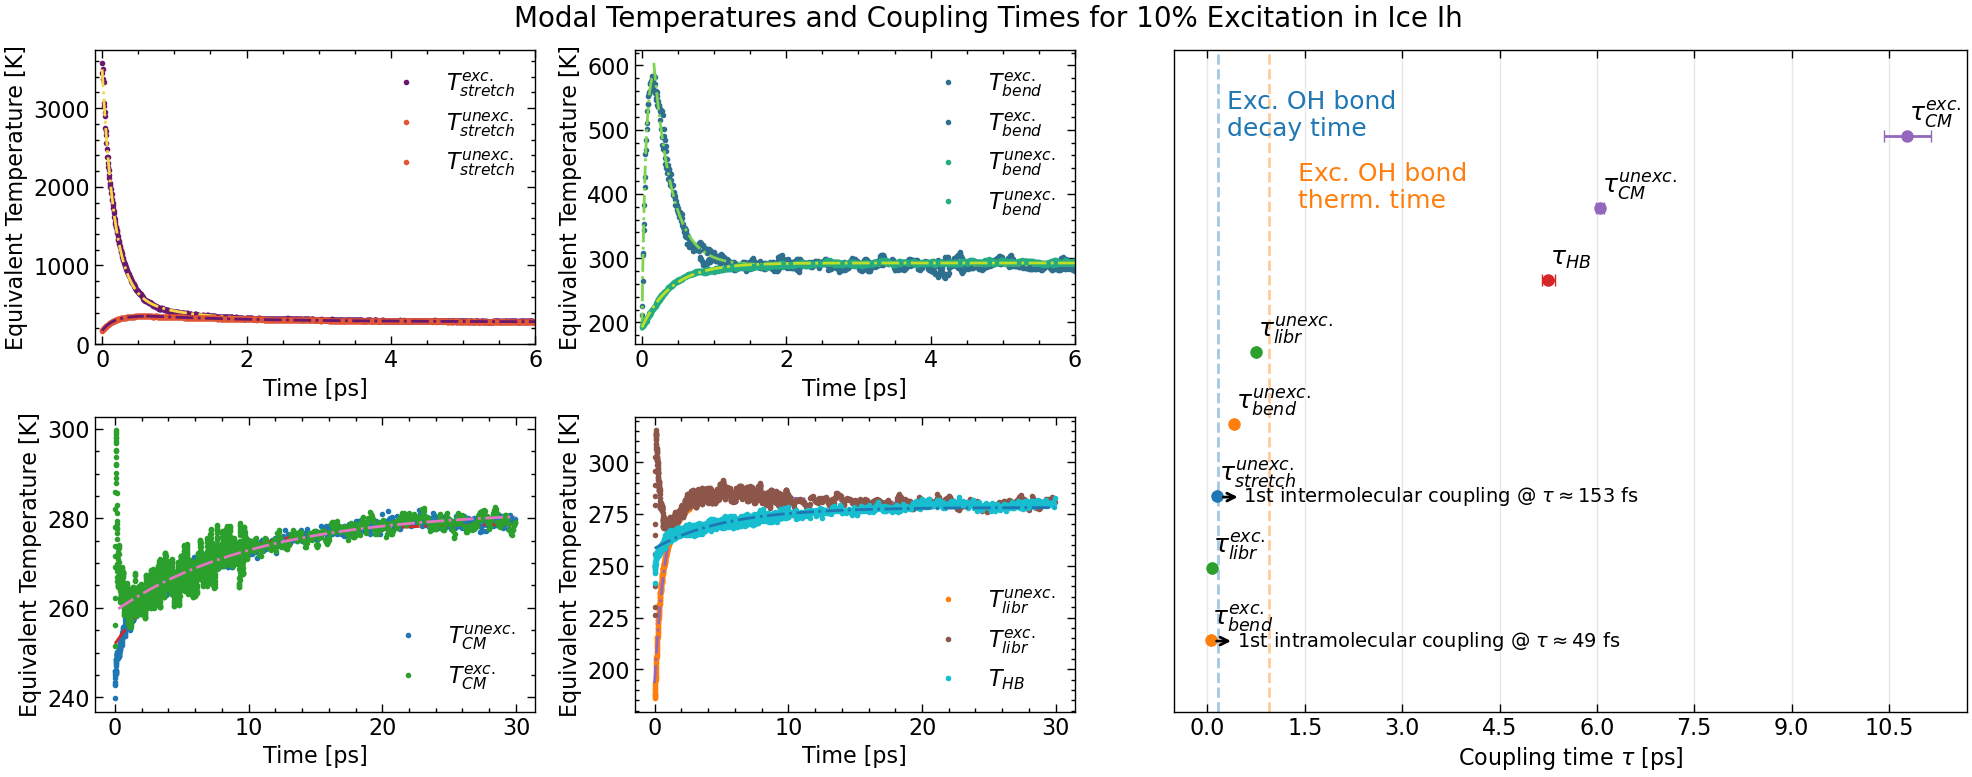

In [8]:
fig = plt.figure(figsize=(20, 8))

gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1.8])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax_big = fig.add_subplot(gs[:, 2])

ax = ax1
ax.plot(OH_exc[0], OH_exc[1], '.', color=C_OH_EXC, label='$T_{{stretch}}^{{exc.}}$')
ax.plot(OH_exc[0], OH_exc[2], '-.', lw=2, color=F_OH_EXC)
ax.plot(OH_norm_heat[0], OH_norm_heat[1], '.', color=C_OH_NORM, label='$T_{{stretch}}^{{unexc.}}$')
ax.plot(OH_norm_heat[0], OH_norm_heat[2], '-.', lw=2, color=F_OH_NORM)
ax.plot(OH_norm_cool[0], OH_norm_cool[1], '.', color=C_OH_NORM, label='_nolegend_')
ax.plot(OH_norm_cool[0], OH_norm_cool[2], '-.', lw=2, color=F_OH_NORM)
ax.legend()
ax.set_xlim(-0.1, 6)
ax.set_xlabel('Time [ps]')
ax.set_ylabel('Equivalent Temperature [K]')

ax = ax3
ax.plot(CMnorm[0], CMnorm[1], '.', color=C_CM_NORM, label='$T_{{CM}}^{{unexc.}}$')
ax.plot(CMnorm[0], CMnorm[2], '-.', lw=2, color=F_CM_NORM)
ax.plot(CMexc[0], CMexc[1], '.', color=C_CM_EXC, label='$T_{{CM}}^{{exc.}}$')
ax.plot(CMexc[0][50:], CMexc[2], '-.', lw=2, color=F_CM_EXC)
ax.legend()
ax.set_xlabel('Time [ps]')
ax.set_ylabel('Equivalent Temperature [K]')

ax = ax2
ax.plot(HOH_exc_heat[0], HOH_exc_heat[1], '.', color=C_HOH_EXC, label='$T_{{bend}}^{{exc.}}$')
ax.plot(HOH_exc_heat[0], HOH_exc_heat[2], '-.', lw=2, color=F_HOH_EXC)
ax.plot(HOH_exc_cool[0], HOH_exc_cool[1], '.', color=C_HOH_EXC, label='_nolegend_')
ax.plot(HOH_exc_cool[0], HOH_exc_cool[2], '-.', lw=2, color=F_HOH_EXC)
ax.plot(HOH_norm_heat[0], HOH_norm_heat[1], '.', color=C_HOH_NORM, label='$T_{{bend}}^{{unexc.}}$')
ax.plot(HOH_norm_heat[0], HOH_norm_heat[2], '-.', lw=2, color=F_HOH_NORM)
ax.plot(HOH_norm_cool[0], HOH_norm_cool[1], '.', color=C_HOH_NORM, label='_nolegend_')
ax.plot(HOH_norm_cool[0], HOH_norm_cool[2], '-.', lw=2, color=F_HOH_NORM)
ax.legend()
ax.set_xlim(-0.1, 6)
ax.set_xlabel('Time [ps]')
ax.set_ylabel('Equivalent Temperature [K]')

ax = ax4
ax.plot(Lmean_norm_heat[0], Lmean_norm_heat[1], '.', color=C_LIBR_NORM, label='$T_{{libr}}^{{unexc.}}$')
ax.plot(Lmean_norm_heat[0], Lmean_norm_heat[2], '-.', lw=2, color=F_LIBR_NORM)
ax.plot(Lmean_norm_cool[0], Lmean_norm_cool[2], '-.', lw=2, color=F_LIBR_NORM)
ax.plot(Lmean_exc[0], Lmean_exc[1], '.', color=C_LIBR_EXC, label='$T_{{libr}}^{{exc.}}$')
ax.plot(HB[0], HB[1], '.', color=C_HB, label='$T_{{HB}}$')
ax.plot(HB[0], HB[2], '-.', lw=2, color=F_HB)
ax.legend()
ax.set_xlabel('Time [ps]')
ax.set_ylabel('Equivalent Temperature [K]')



keys = list(iceIh_10perc_taus.keys())
taus = [val[0] for val in iceIh_10perc_taus.values()]
errs = [val[1] for val in iceIh_10perc_taus.values()]
y = np.arange(len(keys))

def get_color(k):
    tau_color_map = {
        'OH_norm_heat_tau': C_OH_NORM,
        'HOH_exc_heat_tau': C_HOH_EXC,
        'HOH_norm_tau': C_HOH_NORM,
        'CMexc': C_CM_EXC,
        'CMnorm': C_CM_NORM,
        'Lmean_exc_tau': C_LIBR_EXC,
        'Lmean_norm_tau': C_LIBR_NORM,
        'HB_heat_tau': C_HB,
    }
    return tau_color_map.get(k, 'k')

colors = [get_color(k) for k in keys]

for yi, tau, err, key, c in zip(y, taus, errs, keys, colors):
    ax_big.errorbar(
        tau, yi, xerr=err,
        fmt='o', color=c, ecolor=c,
        capsize=4, markersize=8
    )

    label = label_map.get(key, key)
    ax_big.text(
        tau+0.02, yi+0.3, label,
        va='center', ha='left',
        fontsize=18
    )

ax_big.axvline(x=OH_exc_cool_tau_cp[0], color='tab:blue', linestyle='--', alpha=0.4)
ax_big.axvline(x=OH_exc_cool_tau_th[0], color='tab:orange', linestyle='--', alpha=0.4)
ax_big.set_yticks(y)
ax_big.set_yticklabels([''] * len(y))
ax_big.set_xlabel(r'Coupling time $\tau$ [ps]')
ax_big.set_ylim(-1, len(y)+0.2)
# ax_big.set_xlim(left=-0.05, right=4.6)

ax_big.text(
    x=0.3, y = len(y)-1.0,
    s='Exc. stretch\ndecay time',
    color='tab:blue',
    size=18,
)

ax_big.text(
    x=1.4, y = len(y)-2.0,
    s='Exc. stretch\nthermalization time',
    color='tab:orange',
    size=18,
)

ax_big.annotate(f'1st intramolecular coupling @ $\\tau\\approx${HOH_exc_heat_tau[0]*1000:.0f} fs',
                xy=(HOH_exc_heat_tau[0]+0.05, -0.02),
                xytext=(HOH_exc_heat_tau[0]+0.4, -0.1),
                arrowprops=dict(arrowstyle='<-', color='k', lw=2),
                fontsize=14
               )

ax_big.annotate(f'1st intermolecular coupling @ $\\tau\\approx${OH_norm_heat_tau[0]*1000:.0f} fs',
                xy=(OH_norm_heat_tau[0]+0.05, 1.98),
                xytext=(OH_norm_heat_tau[0]+0.4, 1.92),
                arrowprops=dict(arrowstyle='<-', color='k', lw=2),
                fontsize=14
               )


ax_big.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
ax_big.xaxis.set_minor_locator(ticker.NullLocator())

ax_big.set_yticks([])
ax_big.yaxis.set_minor_locator(ticker.NullLocator())

ax_big.grid(True, which='major', alpha=0.3)
ax_big.grid(False, which='minor')

fig.suptitle('Modal Temperatures and Coupling Times for 10% Excitation in Ice Ih', fontsize=20)

plt.tight_layout()
plt.savefig(root / 'plots' / 'IceIh' / 'iceIh_10perc_modal_temps.png', dpi=300)
plt.show()